<h1 align="center">
  <span style="background: linear-gradient(90deg, #ff6ec4, #7873f5); 
               -webkit-background-clip: text; 
               -webkit-text-fill-color: transparent;">
    SONAR DATASET
  </span>
</h1>


---

In [ ]:
import pandas as pd
from torch.utils.data import Dataset 
import torch
from torch.utils.data import random_split
import torch.nn.functional as F
import torch.nn as nn
from csv import writer
import matplotlib.pyplot as plt


Escalamos los datos -> StandardScaler

In [6]:
class StandardScaler:

    def __init__(self, mean=None, std=None, epsilon=1e-7):
        """Standard Scaler.
        The class can be used to normalize PyTorch Tensors using native functions. The module does not expect the
        tensors to be of any specific shape; as long as the features are the last dimension in the tensor, the module
        will work fine.
        :param mean: The mean of the features. The property will be set after a call to fit.
        :param std: The standard deviation of the features. The property will be set after a call to fit.
        :param epsilon: Used to avoid a Division-By-Zero exception.
        """
        self.mean = mean
        self.std = std
        self.epsilon = epsilon
    def fit(self, values):
        dims = list(range(values.dim() - 1))
        self.mean = torch.mean(values, dim=dims)
        self.std = torch.std(values, dim=dims)

    def transform(self, values):
        return (values - self.mean) / (self.std + self.epsilon)

    def fit_transform(self, values):
        self.fit(values)
        return self.transform(values)

    def __repr__(self):
        return f"mean: {self.mean}, std:{self.std}, epsilon:{self.epsilon}"

creamos la clase para el sonar dataset 

Las redes neuronales no pueden leer archivos de excel o CSV, ncesitan que los datos le lleguen en formato de números que serian los tensores y d uno en uno en pequeños grupos.

In [7]:
class SonarDataset(Dataset):
    def __init__(self, src_file, root_dir, transform=None):
        df = pd.read_csv("../../docs/sonar/sonar.all-data.data", header=None)   
        # acordarse siempre de poner la ultima columna porque es el target, la respuesta correcta, lo que queremos que la IA aprenda
        X = df.iloc[:, :-1].values
        
        # y ->es la respuesta (Mina o Roca). Coge solo la última columna ([-1]) osea la target 
        # Como la IA no entiende letraas, cambiamos las ñetras por elñ binario de true or false 1 0 
        y = df.iloc[:, -1].map({'M': 1, 'R': 0}).values
        
        # Convierte las respuestas (y) en un Tensor de PyTorch. 
        # El 'unsqueeze(1)' es para convertir una lista plana [1, 0, 1...] en una columna vertical
        y_tensor = torch.as_tensor(y).type(torch.float32).unsqueeze(1)
        
        # Convierte las features en un Tensor.
        x_tensor = torch.tensor(X, dtype=torch.float32)
        
        # escalado de datos antes de entrenar el modelo para que el modelo aprenda mejor, es decir, para que no se pierda en la escala de los datos, porque si hay una feature con valores muy grandes y otra con valores muy pequeños, el modelo puede tener dificultades para aprender correctamente. El escalado de datos ayuda a que todas las features estén en la misma escala, lo que facilita el aprendizaje del modelo.
        scaler = StandardScaler()
        XScalada = torch.tensor(scaler.fit_transform(x_tensor), dtype=torch.float32)

        # Combina las features escaladas y las respuestas en un solo tensor.
        self.data = torch.cat((XScalada,y_tensor),1)
        
        # Guarda el directorio raíz y la transformación opcional
        self.root_dir = root_dir
        self.transform = transform


    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):
        # A veces PyTorch pide los datos usando tensor en lugar de num normales
        # Esto lo traduce a un número normal de Python para poder buscar la fila sin errores.
        if torch.is_tensor(idx):
            idx = idx.tolist() 
        preds = self.data[idx, 0:60]
        spcs = self.data[idx, 60:]
        # se hace un tupla        
        sample = (preds, spcs)
        
        # Si al crear el dataset habia que escalar , lo hace aquí antes de entregarlo.
        if self.transform:
            sample = self.transform(sample)
        return sample



In [8]:
dataset = SonarDataset("../../docs/sonar/sonar.all-data.data", ".")
display(dataset[0])

/tmp/ipykernel_16581/3487869163.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XScalada = torch.tensor(scaler.fit_transform(x_tensor), dtype=torch.float32)


(tensor([-0.3986, -0.0406, -0.0269, -0.7134,  0.3636, -0.1010,  0.5204,  0.2971,
          1.1226,  0.0211, -0.5660, -0.6570, -0.3512, -1.4110, -1.2374, -0.6498,
         -0.4019, -0.5828,  0.0116, -0.3173, -0.1193, -0.4579, -0.8561, -0.4920,
         -0.0177, -0.2460,  0.0336,  0.4805,  0.1541, -0.8844, -1.7467, -0.8378,
          0.4594,  1.5199,  1.7795,  1.7638,  1.2729,  1.2680,  0.8464, -0.2060,
         -1.3924,  0.0303,  0.2587,  1.5869,  0.4410, -0.1645, -0.1996,  0.6869,
         -0.3791,  0.8764,  0.5938, -1.1127, -0.5962,  0.6792, -0.2949,  1.4780,
          1.7595,  0.0697,  0.1713, -0.6573]),
 tensor([0.]))

Train-Test-Split-> dividimos los datos en dos grupos , el train y el test. 

In [9]:
lenght_dataset = len(dataset)

tamTrain = int(lenght_dataset * 0.8)
tamVal = lenght_dataset - tamTrain  # así evitamos errores de redondeo

print(f"Tam dataset: {lenght_dataset} train: {tamTrain} val: {tamVal}")

train_set, val_set = random_split(dataset, [tamTrain, tamVal])

train_ldr = torch.utils.data.DataLoader(train_set, batch_size=2, shuffle=True, drop_last=False)

validation_loader = torch.utils.data.DataLoader(val_set, batch_size=4, shuffle=False, num_workers=2)


Tam dataset: 208 train: 166 val: 42


---

## MODELO

Perceptrón Multicapa que es una red nueronal Densa Feed-Forward , todos los modelos tienen que heredad de mm.Module

In [ ]:
class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.layer1 = nn.Linear(input_dim, 50)
        self.layer2 = nn.Linear(50, 50)
        self.layer3 = nn.Linear(50, 2)
        
        # como fluyen los datos a traves de esas capas de entrada hasta la salida 
        # aplica la funcion de activación ReLU después de cada capa oculta y una función softmax en la capa de salida para obtener probabilidades de clasificación.
    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = F.softmax(self.layer3(x), dim=1)
        return x

In [11]:
model     = Model(60)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()
display(model)

Model(
  (layer1): Linear(in_features=60, out_features=50, bias=True)
  (layer2): Linear(in_features=50, out_features=50, bias=True)
  (layer3): Linear(in_features=50, out_features=2, bias=True)
)

Testeamos nuestro modelo 

In [12]:
entrada_prueba,dest = next(iter(train_ldr))
print("Entrada:")
display(entrada_prueba)
print("Deseada:")
display(dest)
saida = model(entrada_prueba) 
print("Salida:")
display(saida)
loss_fn(saida, dest)

Entrada:


tensor([[-0.2290, -0.5927,  0.0720, -0.2126, -0.1711, -0.5138,  0.2631, -0.2924,
         -0.3345, -0.5257, -1.0716, -1.6015, -0.8754, -0.0697,  1.2369,  1.9313,
          1.7101,  1.3795,  1.5492,  1.3004,  1.5163,  1.4590,  1.3599,  1.2690,
          0.9206,  1.1488,  1.0801,  0.2921, -0.8269, -0.9002, -0.1485, -0.1798,
         -0.3831, -0.3720, -0.6575, -1.1796, -0.3943, -0.7083, -1.2789, -1.1475,
         -1.2848, -1.4716, -1.1313, -0.5115, -0.4117, -0.9074, -0.7803, -0.7133,
         -0.8853, -0.7994, -0.0474, -0.4484,  0.6219, -0.4028, -1.0568, -0.0735,
         -0.5739, -0.8268, -0.7023, -0.8164],
        [-0.6987, -0.5563, -1.0235, -0.6919, -0.9397, -0.9554, -0.7695, -1.1920,
         -0.3472, -0.0027, -0.0491, -0.3657, -1.0989, -0.6534, -0.1232,  0.6697,
          1.0203,  1.3000,  1.2295,  0.6318,  0.4893,  0.6547,  0.6345, -0.7647,
         -1.9680, -1.7176, -0.3120,  0.6770,  1.0594,  0.9113,  0.0576,  0.2108,
         -0.0650, -0.2687, -0.4155, -0.5662, -0.3914,  0.4909, 

Deseada:


tensor([[0.],
        [1.]])

Salida:


tensor([[0.4496, 0.5504],
        [0.4595, 0.5405]], grad_fn=<SoftmaxBackward0>)

/media/a22nicolesdc/DIURNOEXTRA/programacion/pytorch-1/.venv/lib/python3.13/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([2, 1])) that is different to the input size (torch.Size([2, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


tensor(0.2521, grad_fn=<MseLossBackward0>)

Función de entrenamiento del modelo 

In [13]:
def train_one_epoch(epoch_index, tb_writer):
    running_loss = 0.
    last_loss = 0
    for i, data in enumerate(train_ldr):
        # Every data instance is an input + label pair
        inputs, labels = data
        # Zero your gradients for every batch!
        optimizer.zero_grad()
        # Make predictions for this batch
        outputs = model(inputs)
        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels)
        loss.backward()
        # Adjust learning weights
        optimizer.step()
        # Gather data and report
        running_loss += loss.item()
        if i % 10 == 9:
            last_loss = running_loss / 10 # loss per batch
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            running_loss = 0.
    return last_loss

Entrenamos el modelo 

In [15]:
EPOCHS = 100
loss_list     = torch.zeros((EPOCHS,))
accuracy_list = torch.zeros((EPOCHS,))

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch + 1))

    # le decimos al modelo que estamos en entrenamento 
    model.train(True)
    avg_loss = train_one_epoch(epoch, writer)
    loss_list[epoch] = avg_loss
    # no s necesitan los gradientes para el test
    model.train(False)

EPOCH 1:
  batch 10 loss: 0.25000000596046446
  batch 20 loss: 0.25000000149011614
  batch 30 loss: 0.2500000104308128
  batch 40 loss: 0.25000002086162565
  batch 50 loss: 0.25000001639127734
  batch 60 loss: 0.2500000149011612
  batch 70 loss: 0.2500000029802322
  batch 80 loss: 0.24999999403953552
EPOCH 2:
  batch 10 loss: 0.24999999403953552
  batch 20 loss: 0.25
  batch 30 loss: 0.25000000149011614
  batch 40 loss: 0.25000000149011614
  batch 50 loss: 0.25000000149011614
  batch 60 loss: 0.2500000178813934
  batch 70 loss: 0.2500000178813934
  batch 80 loss: 0.25000000447034837
EPOCH 3:
  batch 10 loss: 0.25000000149011614
  batch 20 loss: 0.25000000596046446
  batch 30 loss: 0.2499999925494194
  batch 40 loss: 0.25000000149011614
  batch 50 loss: 0.2499999985098839
  batch 60 loss: 0.2499999910593033
  batch 70 loss: 0.2499999925494194
  batch 80 loss: 0.24999999701976777
EPOCH 4:
  batch 10 loss: 0.2499999985098839
  batch 20 loss: 0.24999999552965163
  batch 30 loss: 0.25000000

Text(0.5, 0, 'epochs')

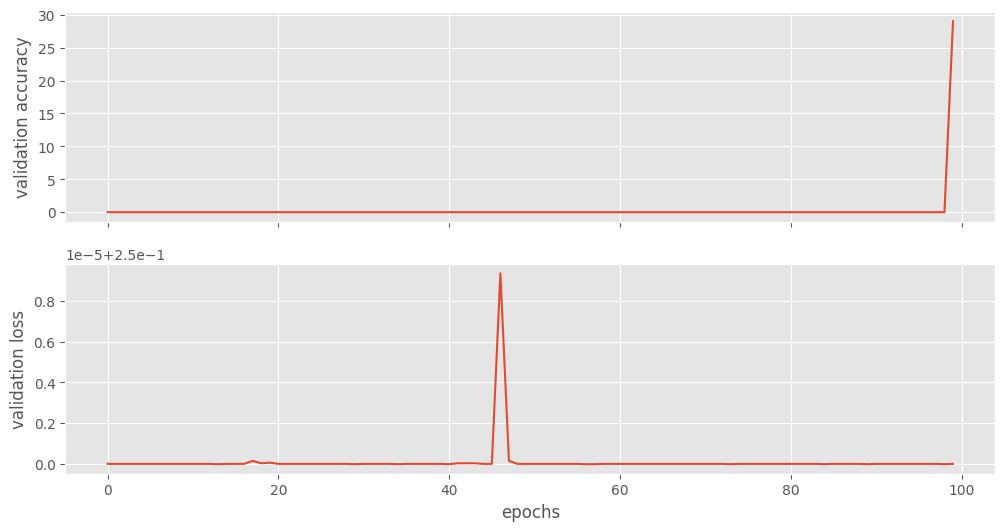

In [17]:
# 1. Le ponemos un estilo visual predefinido para que no se vea feo y soso. 'ggplot' hace que tenga un fondo gris y una cuadrícula bonita.
plt.style.use('ggplot')

# 2. Creamos la estructura. 'fig' es la ventana entera. '(ax1, ax2)' son los dos gráficos.
# figsize=(12, 6) dice que mida 12 de ancho por 6 de alto.
# sharex=True es un truco genial: hace que ambos gráficos compartan el eje X (las épocas) para no repetir números abajo.
fig, (ax1, ax2) = plt.subplots(2, figsize=(12, 6), sharex=True)

# 3. En el gráfico de arriba (ax1), dibujamos la línea con la lista de aciertos.
ax1.plot(accuracy_list)
# 4. Le ponemos una etiqueta al lado vertical izquierdo de arriba para saber qué es.
ax1.set_ylabel("validation accuracy")

# 5. En el gráfico de abajo (ax2), dibujamos la línea con la lista de errores.
ax2.plot(loss_list)
# 6. Le ponemos su etiqueta al lado vertical izquierdo de abajo.
ax2.set_ylabel("validation loss")

# 7. Como el eje X es compartido, se lo ponemos solo al gráfico de abajo (ax2) para que sirva para los dos.
ax2.set_xlabel("epochs")